In [1]:
from pathlib import Path
import base64
import io
import json
import random
import zlib
import os
from typing import Dict, List, Optional, Tuple

import segmentation_models_pytorch as smp
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import functional as TF
from torchvision.transforms import InterpolationMode
import pandas as pd


# Root folders
PROJECT_ROOT = Path.cwd()
DATASET_ROOT = PROJECT_ROOT / "dataset"
META_PATH = DATASET_ROOT / "meta.json"

BATCH_SIZE = 5
NUM_EPOCHS = 10
LEARNING_RATE = 1e-4
# BASE_ENCODER = "resnet18"
# BASE_ENCODER = "resnet34"
BASE_ENCODER = "resnet50"
# BASE_ENCODER = "mobilenet_v2"
# BASE_ENCODER = "senet154"
MODEL_PATH = f"{BASE_ENCODER}_food_seg.pth"

if not META_PATH.exists():
    # Fallback in case notebook is launched from parent folder
    PROJECT_ROOT = PROJECT_ROOT / "HSS Project"
    DATASET_ROOT = PROJECT_ROOT / "dataset"
    META_PATH = DATASET_ROOT / "meta.json"

with open(META_PATH, "r", encoding="utf-8") as f:
    meta = json.load(f)

classes = meta["classes"]
class_id_to_train_id: Dict[int, int] = {}
train_id_to_class_name: Dict[int, str] = {0: "background"}
train_id_to_color: Dict[int, Tuple[int, int, int]] = {0: (0, 0, 0)}

for idx, cls in enumerate(classes, start=1):
    class_id_to_train_id[cls["id"]] = idx
    train_id_to_class_name[idx] = cls["title"]
    color_hex = cls.get("color", "#FFFFFF").lstrip("#")
    train_id_to_color[idx] = tuple[int, int, int](int(color_hex[i:i+2], 16) for i in (0, 2, 4))

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

print(f"Dataset root: {DATASET_ROOT}")
print(f"Classes: {len(classes)} (+ background)")
print("device:", device)

Dataset root: u:\Dev\AI\HSS Project\dataset
Classes: 103 (+ background)
device: cuda:0


In [2]:
def decode_bitmap_to_canvas(bitmap_data: str, origin: List[int], canvas_h: int, canvas_w: int) -> np.ndarray:
    """Decode Supervisely-style bitmap into a full-size binary mask."""
    packed_bytes = base64.b64decode(bitmap_data)

    # FoodSeg/Supervisely stores zlib-compressed PNG bytes in bitmap.data.
    try:
        png_bytes = zlib.decompress(packed_bytes)
    except zlib.error:
        # Fallback for already-uncompressed payloads.
        png_bytes = packed_bytes

    bitmap = Image.open(io.BytesIO(png_bytes)).convert("RGBA")
    bitmap_arr = np.array(bitmap)

    # Alpha channel carries the actual bitmap region.
    local_mask = bitmap_arr[..., 3] > 0

    x0, y0 = int(origin[0]), int(origin[1])
    h, w = local_mask.shape

    canvas = np.zeros((canvas_h, canvas_w), dtype=bool)

    x1 = max(0, x0)
    y1 = max(0, y0)
    x2 = min(canvas_w, x0 + w)
    y2 = min(canvas_h, y0 + h)

    if x1 >= x2 or y1 >= y2:
        return canvas

    src_x1 = x1 - x0
    src_y1 = y1 - y0
    src_x2 = src_x1 + (x2 - x1)
    src_y2 = src_y1 + (y2 - y1)

    canvas[y1:y2, x1:x2] = local_mask[src_y1:src_y2, src_x1:src_x2]
    return canvas


class FoodSegDataset(Dataset):
    def __init__(
        self,
        dataset_root: Path,
        split: str = "train",
        class_id_to_train_id: Optional[Dict[int, int]] = None,
        augment: bool = False,
        hflip_prob: float = 0.5,
        vflip_prob: float = 0.0,
        rot90_prob: float = 0.3,
        brightness_prob: float = 0.3,
        brightness_strength: float = 0.2,
        seed: Optional[int] = None,
        image_size: int = 448,
        normalize_imagenet: bool = True,
    ):
        assert split in {"train", "test"}, "split must be 'train' or 'test'"
        self.dataset_root = Path(dataset_root)
        self.split = split
        self.img_dir = self.dataset_root / split / "img"
        self.ann_dir = self.dataset_root / split / "ann"

        self.class_id_to_train_id = class_id_to_train_id or {}
        self.augment = augment and split == "train"
        self.hflip_prob = hflip_prob
        self.vflip_prob = vflip_prob
        self.rot90_prob = rot90_prob
        self.brightness_prob = brightness_prob
        self.brightness_strength = brightness_strength
        self.rng = random.Random(seed)
        self.image_size = (image_size, image_size) if isinstance(image_size, int) else tuple(image_size)
        self.normalize_imagenet = normalize_imagenet

        self.samples = []
        for ann_path in sorted(self.ann_dir.glob("*.json")):
            img_name = ann_path.name.replace(".json", "")
            img_path = self.img_dir / img_name
            if img_path.exists():
                self.samples.append((img_path, ann_path))

        if len(self.samples) == 0:
            raise RuntimeError(f"No samples found for split={split} in {self.dataset_root}")

    def __len__(self) -> int:
        return len(self.samples)

    def _build_mask_from_annotation(self, ann: dict) -> np.ndarray:
        h = int(ann["size"]["height"])
        w = int(ann["size"]["width"])
        sem_mask = np.zeros((h, w), dtype=np.int64)

        for obj in ann.get("objects", []):
            if obj.get("geometryType") != "bitmap":
                continue
            bitmap = obj.get("bitmap")
            if bitmap is None:
                continue

            class_id = obj.get("classId")
            train_id = self.class_id_to_train_id.get(class_id, 0)
            obj_mask = decode_bitmap_to_canvas(
                bitmap_data=bitmap["data"],
                origin=bitmap["origin"],
                canvas_h=h,
                canvas_w=w,
            )
            sem_mask[obj_mask] = train_id

        return sem_mask

    def _apply_augmentations(self, image: np.ndarray, mask: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
        # Geometric transforms must be applied to image and mask together.
        if self.rng.random() < self.hflip_prob:
            image = np.ascontiguousarray(np.fliplr(image))
            mask = np.ascontiguousarray(np.fliplr(mask))

        if self.rng.random() < self.vflip_prob:
            image = np.ascontiguousarray(np.flipud(image))
            mask = np.ascontiguousarray(np.flipud(mask))

        if self.rng.random() < self.rot90_prob:
            k = self.rng.choice([1, 2, 3])
            image = np.ascontiguousarray(np.rot90(image, k=k))
            mask = np.ascontiguousarray(np.rot90(mask, k=k))

        # Photometric transform is image-only.
        if self.rng.random() < self.brightness_prob:
            factor = 1.0 + self.rng.uniform(-self.brightness_strength, self.brightness_strength)
            image = np.clip(image.astype(np.float32) * factor, 0, 255).astype(np.uint8)

        return image, mask

    def __getitem__(self, idx: int):
        img_path, ann_path = self.samples[idx]

        image = np.array(Image.open(img_path).convert("RGB"), dtype=np.uint8)
        with open(ann_path, "r", encoding="utf-8") as f:
            ann = json.load(f)

        mask = self._build_mask_from_annotation(ann)

        if self.augment:
            image, mask = self._apply_augmentations(image, mask)

        image_tensor = torch.from_numpy(image).permute(2, 0, 1).float() / 255.0
        mask_tensor = torch.from_numpy(mask).long()

        # Resize and pad images/masks so their longest side is 1024, and if smaller, pad to exactly 1024x1024.

        # Get original height and width
        h, w = image.shape[:2]
        max_size = 576

        # Compute scaling factor (do not upscale larger dimension beyond 1024)
        scale = min(max_size / max(h, w), 1.0)
        new_h, new_w = int(round(h * scale)), int(round(w * scale))

        # Resize the image and mask to new size
        image_tensor = TF.resize(
            image_tensor,
            [new_h, new_w],
            interpolation=InterpolationMode.BILINEAR,
        )
        mask_tensor = TF.resize(
            mask_tensor.unsqueeze(0).float(),
            [new_h, new_w],
            interpolation=InterpolationMode.NEAREST,
        ).squeeze(0).long()

        # Compute padding for height and width to get to max_size
        pad_h = max_size - new_h
        pad_w = max_size - new_w
        pad_top = pad_h // 2
        pad_bottom = pad_h - pad_top
        pad_left = pad_w // 2
        pad_right = pad_w - pad_left

        # Pad both image and mask to 1024x1024
        image_tensor = TF.pad(
            image_tensor,
            [pad_left, pad_top, pad_right, pad_bottom],
            fill=0
        )
        mask_tensor = TF.pad(
            mask_tensor,
            [pad_left, pad_top, pad_right, pad_bottom],
            fill=0
        )

        if self.normalize_imagenet:
            image_tensor = TF.normalize(
                image_tensor,
                mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225],
            )

        sample_info = {
            "image_path": str(img_path),
            "annotation_path": str(ann_path),
            "split": self.split,
            "index": idx,
        }
        return image_tensor, mask_tensor, sample_info

In [3]:
def colorize_mask(mask: np.ndarray, train_id_to_color: Dict[int, Tuple[int, int, int]]) -> np.ndarray:
    h, w = mask.shape
    color_mask = np.zeros((h, w, 3), dtype=np.uint8)

    for train_id in np.unique(mask):
        color = train_id_to_color.get(int(train_id), (255, 255, 255))
        color_mask[mask == train_id] = color

    return color_mask


def overlay_image_with_mask(image: np.ndarray, color_mask: np.ndarray, alpha: float = 0.45) -> np.ndarray:
    image_f = image.astype(np.float32)
    mask_f = color_mask.astype(np.float32)
    overlay = np.clip((1.0 - alpha) * image_f + alpha * mask_f, 0, 255).astype(np.uint8)
    return overlay


def show_sample(
    image_tensor: torch.Tensor,
    mask_tensor: torch.Tensor,
    train_id_to_class_name: Dict[int, str],
    train_id_to_color: Dict[int, Tuple[int, int, int]],
    alpha: float = 0.45,
    max_legend_items: int = 15,
    denormalize_imagenet: bool = True,
    imagenet_mean: Tuple[float, float, float] = (0.485, 0.456, 0.406),
    imagenet_std: Tuple[float, float, float] = (0.229, 0.224, 0.225),
):
    img = image_tensor.detach().float().cpu()
    if denormalize_imagenet:
        mean = torch.tensor(imagenet_mean, dtype=img.dtype).view(3, 1, 1)
        std = torch.tensor(imagenet_std, dtype=img.dtype).view(3, 1, 1)
        img = (img * std + mean).clamp(0.0, 1.0)
    image = (img.permute(1, 2, 0).numpy() * 255.0).clip(0, 255).astype(np.uint8)
    mask = mask_tensor.cpu().numpy().astype(np.int64)

    color_mask = colorize_mask(mask, train_id_to_color)
    overlay = overlay_image_with_mask(image, color_mask, alpha=alpha)

    uniq_ids = [int(x) for x in np.unique(mask) if int(x) != 0]

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    axes[0].imshow(image)
    axes[0].set_title("Image")
    axes[0].axis("off")

    axes[1].imshow(color_mask)
    axes[1].set_title("Mask (colorized)")
    axes[1].axis("off")

    axes[2].imshow(overlay)
    axes[2].set_title("Overlay")
    axes[2].axis("off")

    if len(uniq_ids) > 0:
        legend_items = []
        for train_id in uniq_ids[:max_legend_items]:
            name = train_id_to_class_name.get(train_id, f"class_{train_id}")
            legend_items.append(f"{train_id}: {name}")

        legend_title = "Classes in sample"
        if len(uniq_ids) > max_legend_items:
            legend_title += f" (first {max_legend_items})"

        fig.suptitle(" | ".join(legend_items), fontsize=10, y=1.03)

    plt.tight_layout()
    plt.show()

In [4]:
train_ds = FoodSegDataset(
    dataset_root=DATASET_ROOT,
    split="train",
    class_id_to_train_id=class_id_to_train_id,
    # augment=False
    augment=True,
    hflip_prob=0.5,
    vflip_prob=0.1,
    rot90_prob=0.25,
    brightness_prob=0.35,
    brightness_strength=0.2,
    seed=42,
)


def collate_segmentation(batch):
    """Stack (image, mask, info) batches into tensors only — matches train loop `for x, y`."""
    images = torch.stack([b[0] for b in batch], dim=0)
    masks = torch.stack([b[1] for b in batch], dim=0)
    return images, masks


train_dl = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_segmentation,
)

test_ds = FoodSegDataset(
    dataset_root=DATASET_ROOT,
    split="test",
    class_id_to_train_id=class_id_to_train_id,
    augment=False,
)
test_dl = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_segmentation,
)

print(f"train samples: {len(train_ds)}")
print(f"test samples:  {len(test_ds)}")

train samples: 4983
test samples:  2135


Sample info: {'image_path': 'u:\\Dev\\AI\\HSS Project\\dataset\\train\\img\\00000000.jpg', 'annotation_path': 'u:\\Dev\\AI\\HSS Project\\dataset\\train\\ann\\00000000.jpg.json', 'split': 'train', 'index': 0}
Image shape: (3, 576, 576)
Mask shape: (576, 576)
Unique class ids (sample): [0, 22, 81, 89] 


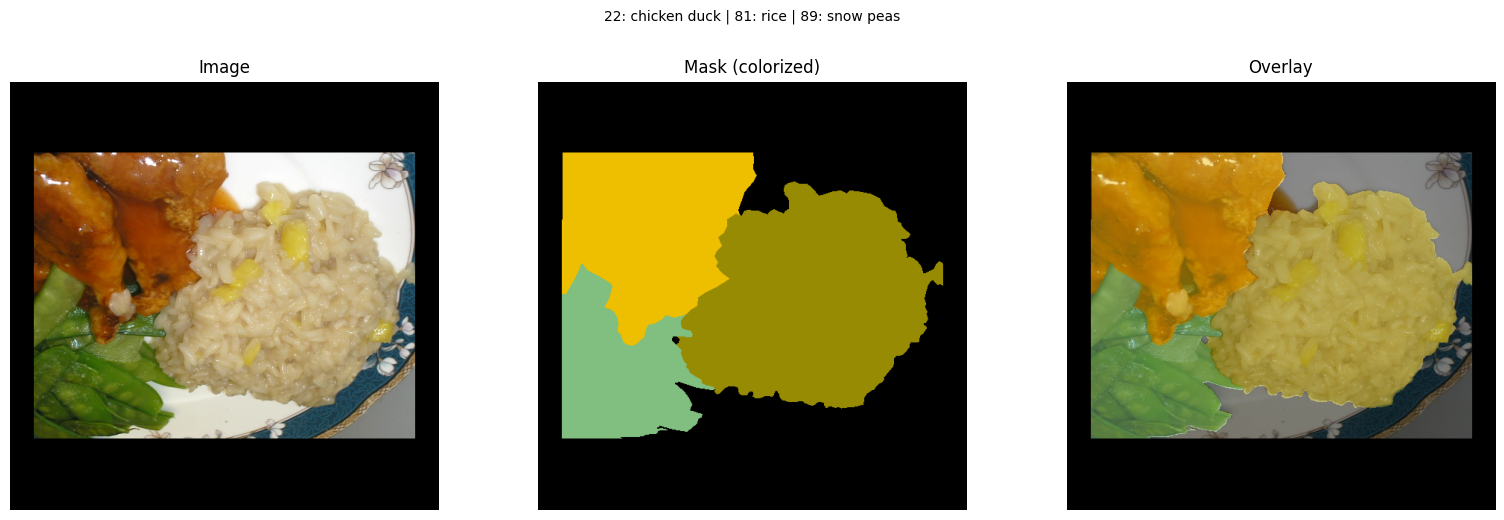

In [5]:
# Sanity-check for one train sample
img_t, mask_t, info = train_ds[0]

assert img_t.ndim == 3 and img_t.shape[0] == 3, "Image tensor must be [3, H, W]"
assert mask_t.ndim == 2, "Mask tensor must be [H, W]"
assert img_t.shape[1:] == mask_t.shape, "Image and mask spatial sizes must match"
# assert tuple(img_t.shape[1:]) == train_ds.image_size, "Spatial size must match dataset.image_size"
assert img_t.dtype == torch.float32, "Image dtype must be float32"
assert mask_t.dtype == torch.int64, "Mask dtype must be int64"

uniq = torch.unique(mask_t).cpu().numpy().tolist()
print("Sample info:", info)
print("Image shape:", tuple(img_t.shape))
print("Mask shape:", tuple(mask_t.shape))
print("Unique class ids (sample):", uniq[:30], "..." if len(uniq) > 30 else "")

show_sample(img_t, mask_t, train_id_to_class_name, train_id_to_color, alpha=0.45)

Train examples
idx=2275 | 00002279.jpg


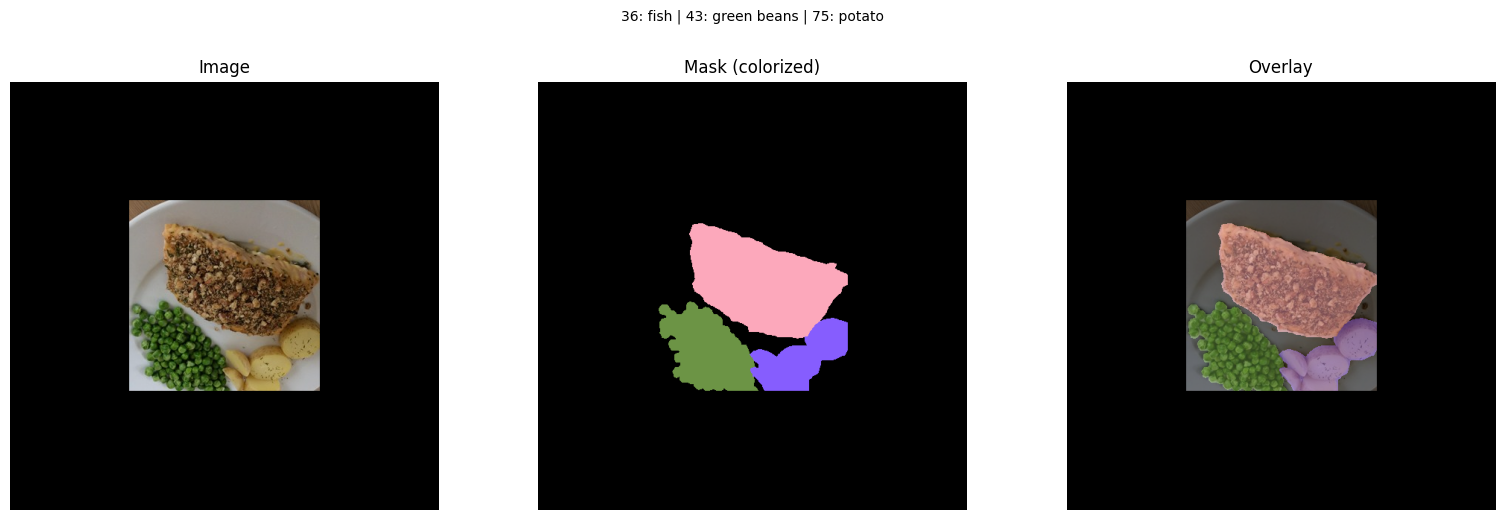

idx=4491 | 00006375.jpg


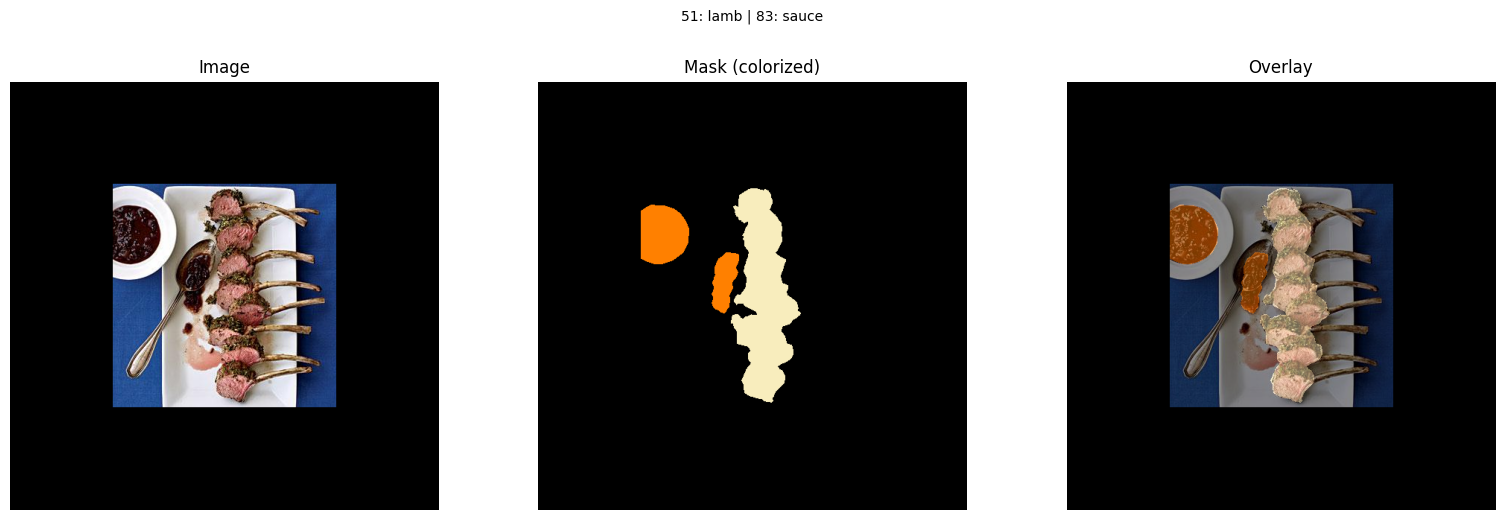

Test examples
idx=23 | 00004420.jpg


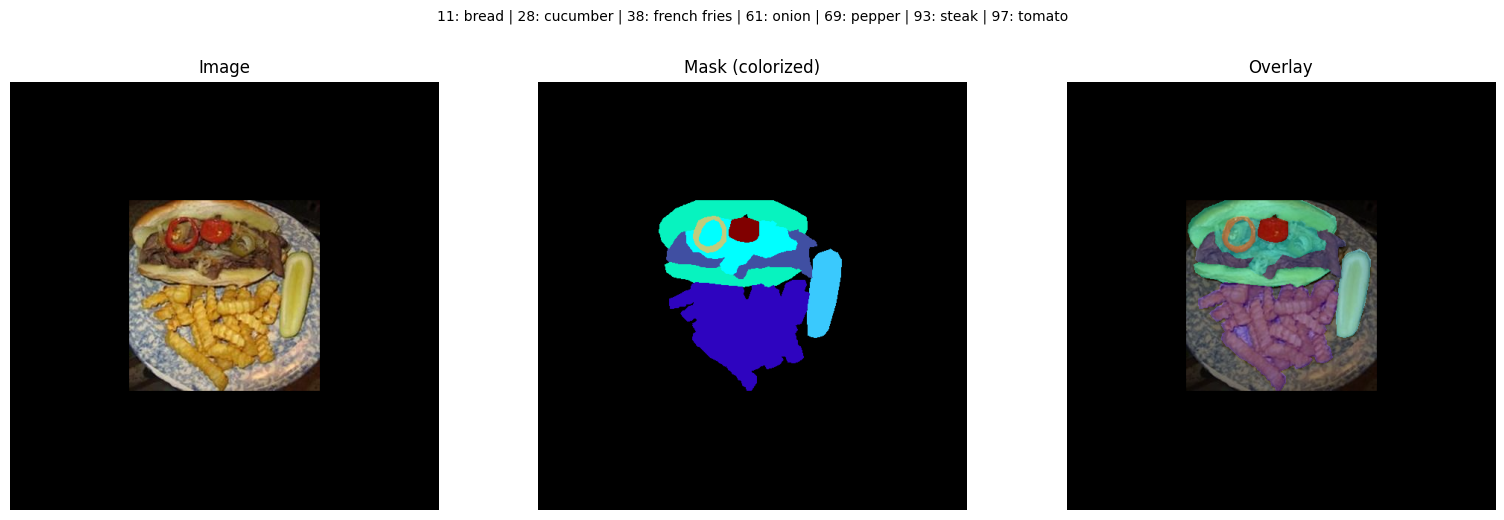

idx=725 | 00005122.jpg


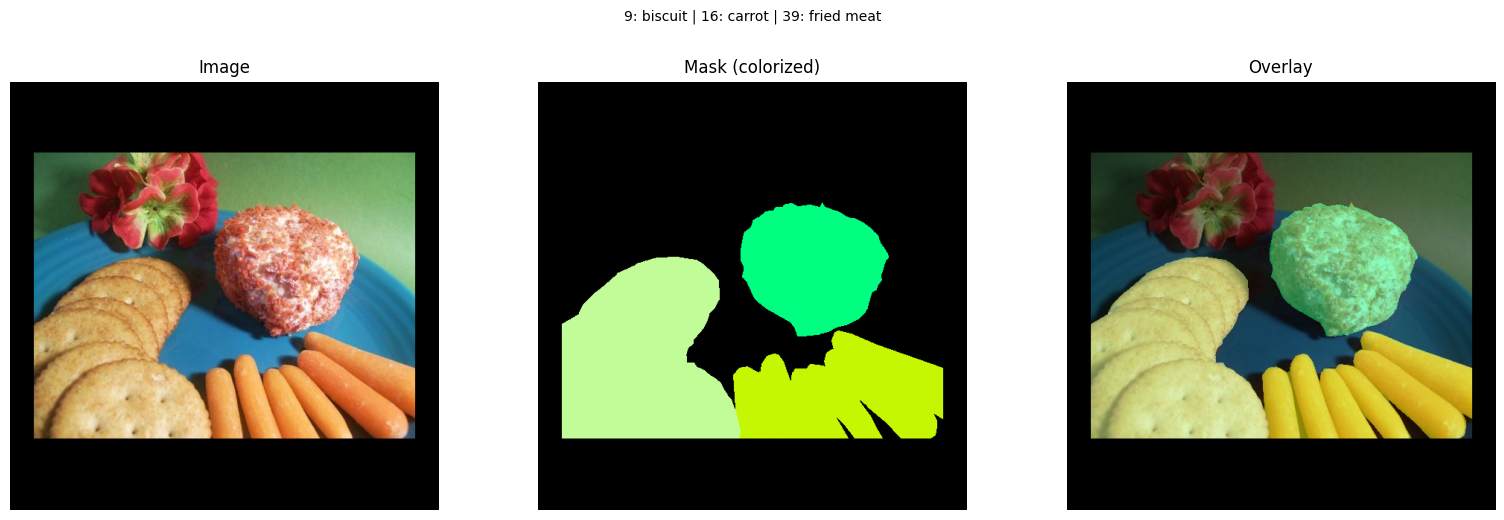

In [6]:
# Visual check on several random train/test samples
rng = random.Random(124)

train_indices = [rng.randrange(len(train_ds)) for _ in range(2)]
test_indices = [rng.randrange(len(test_ds)) for _ in range(2)]

print("Train examples")
for idx in train_indices:
    img_t, mask_t, info = train_ds[idx]
    print(f"idx={idx} | {Path(info['image_path']).name}")
    show_sample(img_t, mask_t, train_id_to_class_name, train_id_to_color, alpha=0.45)

print("Test examples")
for idx in test_indices:
    img_t, mask_t, info = test_ds[idx]
    print(f"idx={idx} | {Path(info['image_path']).name}")
    show_sample(img_t, mask_t, train_id_to_class_name, train_id_to_color, alpha=0.45)

In [7]:
train_skip = False
model = smp.UPerNet(
        encoder_name=BASE_ENCODER,
        encoder_weights="imagenet",
        # encoder_weights=None,
        activation=None,
        in_channels=3,
        classes=len(classes) + 1,
    )
# model = smp.DeepLabV3Plus(
#         encoder_name=BASE_ENCODER,
#         encoder_weights="imagenet",
#         # encoder_weights=None,
#         activation=None,
#         in_channels=3,
#         classes=len(classes) + 1,
#     )
# model = smp.Segformer(
#         encoder_name=BASE_ENCODER,
#         encoder_weights="imagenet",
#         # encoder_weights=None,
#         activation=None,
#         in_channels=3,
#         classes=len(classes) + 1,
#     )
if os.path.exists(MODEL_PATH):
    model_weights = torch.load(MODEL_PATH, weights_only=True, map_location=device)
    model.load_state_dict(model_weights)
    train_skip = True

model.to(device)
loss = smp.losses.DiceLoss(mode="multiclass")
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

In [8]:
def segmentation_pred_classes(logits: torch.Tensor) -> torch.Tensor:
    """(N,C,H,W) -> (N,H,W) integer class indices; binary uses sigmoid threshold 0.5."""
    if logits.shape[1] == 1:
        return (logits > 0.5).squeeze(1).long()
    return torch.argmax(logits, dim=1)


def iou_per_class(pred: torch.Tensor, target: torch.Tensor, num_classes: int) -> list[float]:
    """pred, target: (N, H, W) integer class indices."""
    ious = []
    pred = pred.view(-1)
    target = target.view(-1)
    for c in range(num_classes):
        p = pred == c
        t = target == c
        inter = (p & t).sum().float()
        union = (p | t).sum().float()
        ious.append((inter / union).item() if union > 0 else float("nan"))
    return ious


def mean_iou_from_batches(batch_ious: list[list[float]]) -> float:
    """Mean per-class IoU over batches, then mean over classes (NaNs ignored)."""
    if not batch_ious:
        return float("nan")
    arr = np.asarray(batch_ious, dtype=np.float64)
    per_class = np.nanmean(arr, axis=0)
    return float(np.nanmean(per_class))


def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running = 0.0
    n = 0
    ious: list[list[float]] = []
    pbar = tqdm(loader, desc="train", leave=False)
    for x, y in pbar:
        x = x.to(device)
        y = y.to(device).long()  # (N,H,W) class indices — DiceLoss multiclass needs LongTensor
        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        running += loss.item() * x.size(0)
        n += x.size(0)
        pred_cls = segmentation_pred_classes(logits)
        batch_iou = iou_per_class(pred_cls, y, len(classes) + 1)
        ious.append(batch_iou)
        pbar.set_postfix(loss=loss.item(), iou=mean_iou_from_batches(ious))
    return running / max(n, 1), mean_iou_from_batches(ious)


def val_one_epoch(model, loader, criterion, device):
    model.eval()
    running = 0.0
    n = 0
    ious: list[list[float]] = []
    with torch.no_grad():
        for x, y in tqdm(loader, desc="val", leave=False):
            x = x.to(device)
            y = y.to(device).long()
            logits = model(x)
            loss = criterion(logits, y)
            running += loss.item() * x.size(0)
            n += x.size(0)
            pred_cls = segmentation_pred_classes(logits)
            ious.append(iou_per_class(pred_cls, y, len(classes) + 1))
    return running / max(n, 1), mean_iou_from_batches(ious)


In [13]:
history = []
best_iou = 0
if not train_skip:
    for epoch in range(NUM_EPOCHS):
        print(f"{'-'*20}Epoch {epoch+1}/{NUM_EPOCHS}{'-'*20}")
        train_loss, train_iou = train_one_epoch(model, train_dl, optimizer, loss, device)
        val_loss, val_iou = val_one_epoch(model, test_dl, loss, device)
        history.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "train_iou": train_iou,
            "val_loss": val_loss,
            "val_iou": val_iou
        })
        print(f"Train Loss: {train_loss:.4f}, Train IoU: {train_iou:.4f}\nVal Loss: {val_loss:.4f}, Val IoU: {val_iou:.4f}")
        print(f"{'-'*50}")
        if (val_iou > best_iou):
            best_iou = val_iou
            torch.save(model.state_dict(), MODEL_PATH)

--------------------Epoch 1/10--------------------


train:   0%|          | 0/997 [00:00<?, ?it/s]C:\Users\Serge\AppData\Local\Temp\ipykernel_12596\2647990030.py:27: RuntimeWarning: Mean of empty slice
  per_class = np.nanmean(arr, axis=0)


Train Loss: 0.0716, Train IoU: 0.0855
Val Loss: 0.0770, Val IoU: 0.0901
--------------------------------------------------
--------------------Epoch 2/10--------------------


Train Loss: 0.0697, Train IoU: 0.0896
Val Loss: 0.0741, Val IoU: 0.0926
--------------------------------------------------
--------------------Epoch 3/10--------------------


Train Loss: 0.0683, Train IoU: 0.0928
Val Loss: 0.0746, Val IoU: 0.0922
--------------------------------------------------
--------------------Epoch 4/10--------------------


Train Loss: 0.0664, Train IoU: 0.0945
Val Loss: 0.0747, Val IoU: 0.0908
--------------------------------------------------
--------------------Epoch 5/10--------------------


Train Loss: 0.0653, Train IoU: 0.0965
Val Loss: 0.0728, Val IoU: 0.0936
--------------------------------------------------
--------------------Epoch 6/10--------------------


KeyboardInterrupt: 

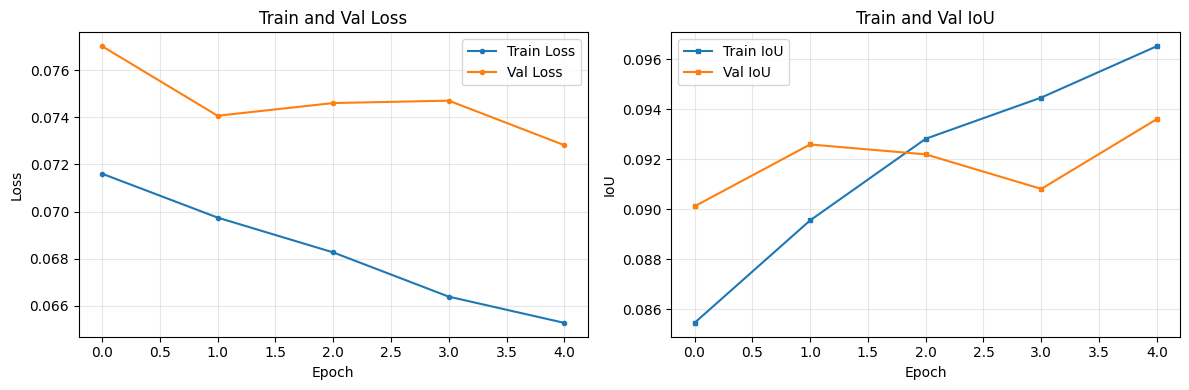

In [14]:
if len(history) > 0:
    hist_df = pd.DataFrame(history)
    # Plot Train and Val Loss
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(hist_df["epoch"], hist_df["train_loss"], marker="o", ms=3, label="Train Loss")
    plt.plot(hist_df["epoch"], hist_df["val_loss"], marker="o", ms=3, label="Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Train and Val Loss")
    plt.grid(True, alpha=0.3)
    plt.legend()

    # Plot Train and Val IoU
    plt.subplot(1, 2, 2)
    plt.plot(hist_df["epoch"], hist_df["train_iou"], marker="s", ms=3, label="Train IoU")
    plt.plot(hist_df["epoch"], hist_df["val_iou"], marker="s", ms=3, label="Val IoU")
    plt.xlabel("Epoch")
    plt.ylabel("IoU")
    plt.title("Train and Val IoU")
    plt.grid(True, alpha=0.3)
    plt.legend()

    plt.tight_layout()
    plt.show()

Test pixel acc: 0.8386
Test Dice loss: 0.0733
Test mean IoU:  0.0940


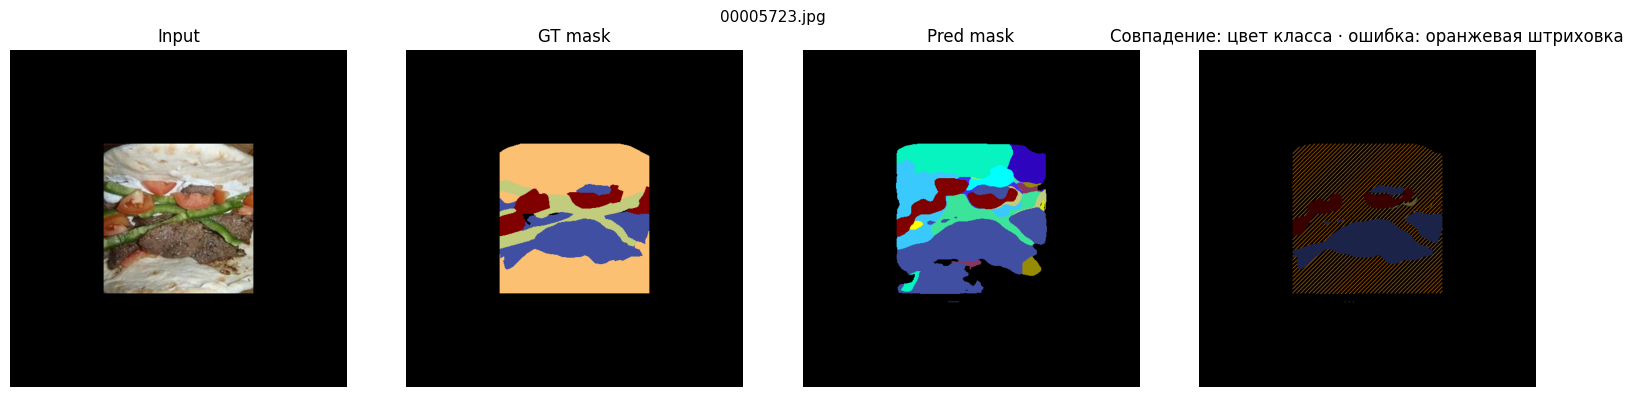

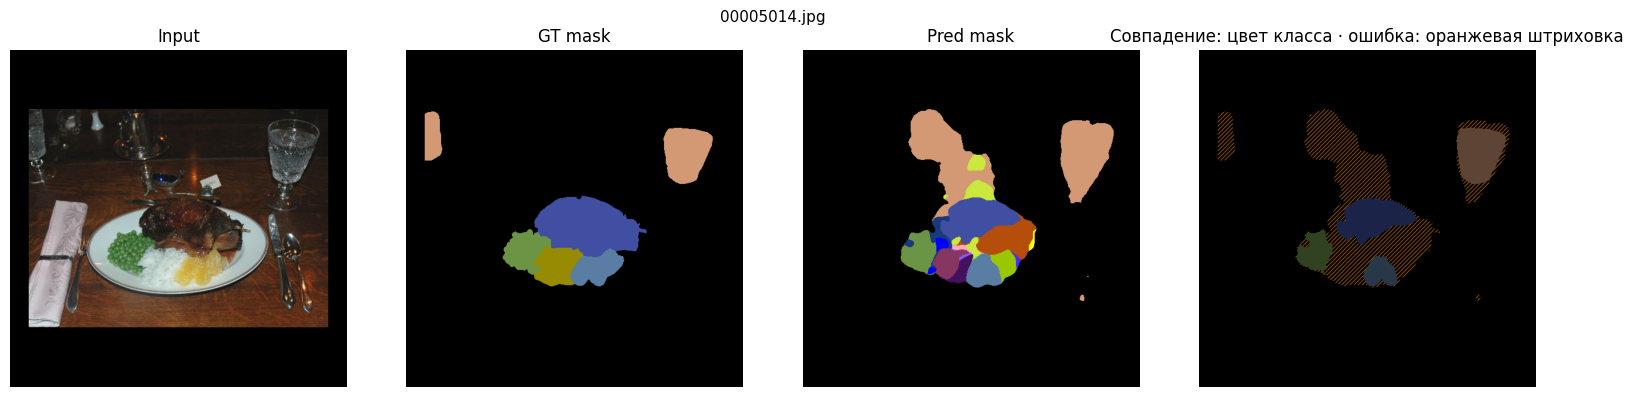

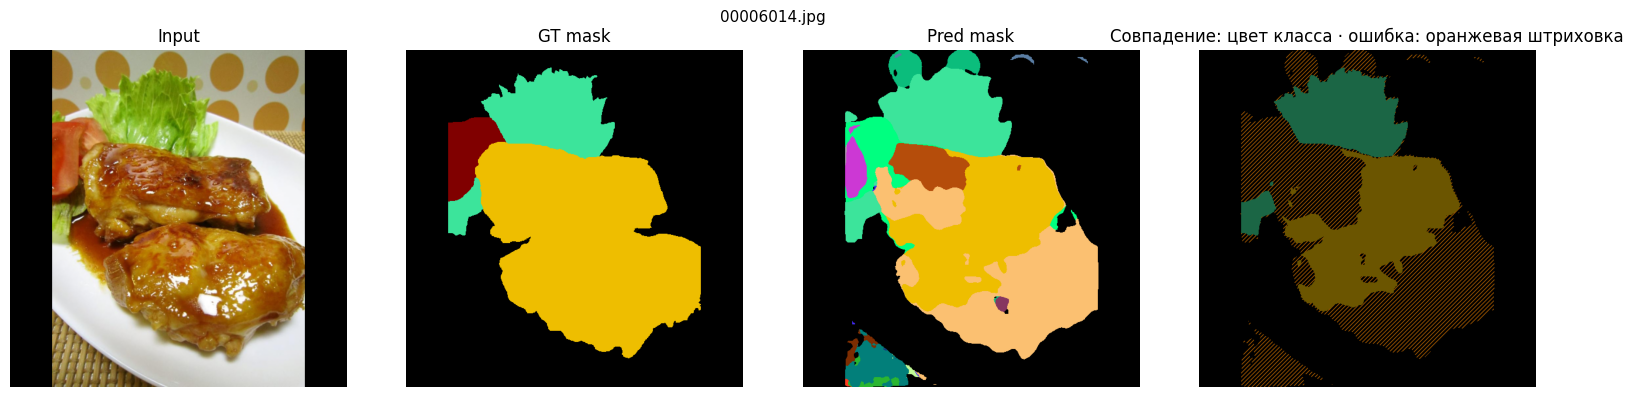

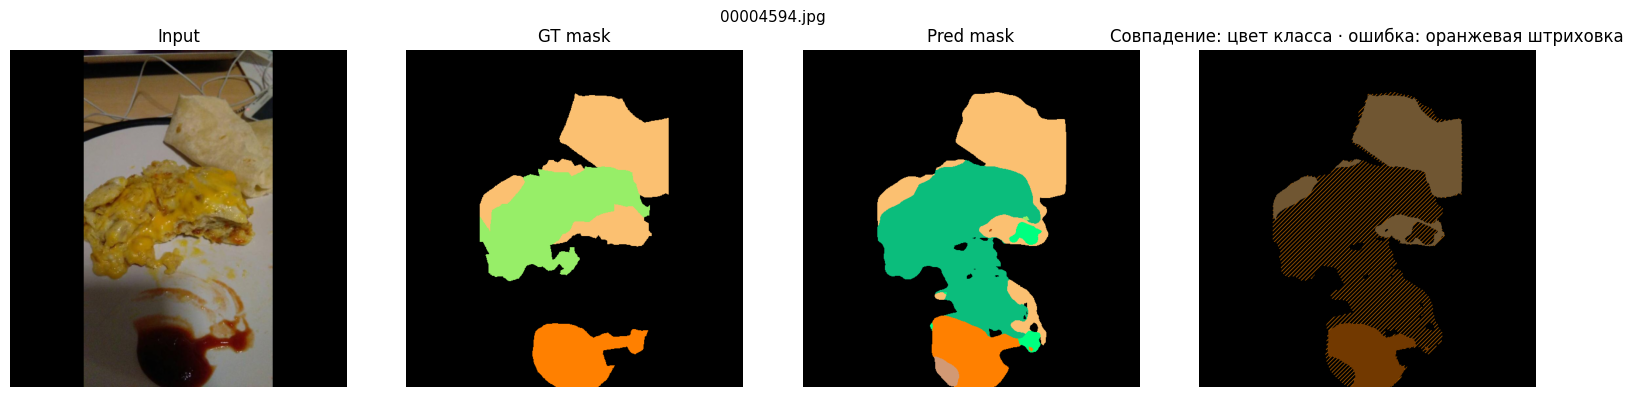

In [15]:
# Test-set evaluation + mask visualization (GT vs prediction)


def overlay_match_and_mismatch(
    image: np.ndarray,
    gt: np.ndarray,
    pred: np.ndarray,
    train_id_to_color: Dict[int, Tuple[int, int, int]],
    alpha_match: float = 0.45,
    hatch_blend: float = 0.62,
    stripe_period: int = 7,
    stripe_width: int = 2,
) -> np.ndarray:
    """Совпадение pred/GT: полупрозрачный цвет класса на чёрном фоне. Расхождение: оранжевые диагональные штрихи на чёрном фоне."""
    h, w = gt.shape
    black_bg = np.zeros((h, w, 3), dtype=np.float32)
    agree = pred == gt
    gt_color = colorize_mask(gt, train_id_to_color).astype(np.float32)
    yy, xx = np.ogrid[0:h, 0:w]
    diag = (xx + yy) % stripe_period
    stripe = diag < stripe_width
    orange = np.array([255, 140, 0], dtype=np.float32)
    agree_3 = agree[..., np.newaxis]
    stripe_3 = stripe[..., np.newaxis]
    matched = (1.0 - alpha_match) * black_bg + alpha_match * gt_color
    mismatched = np.where(
        stripe_3,
        (1.0 - hatch_blend) * black_bg + hatch_blend * orange,
        black_bg,
    )
    out = np.where(agree_3, matched, mismatched)
    return np.clip(out, 0, 255).astype(np.uint8)


def show_pred_vs_gt(
    image_tensor: torch.Tensor,
    gt_mask_tensor: torch.Tensor,
    pred_mask_tensor: torch.Tensor,
    title: str = "",
    alpha: float = 0.45,
):
    img = image_tensor.detach().float().cpu()
    mean = torch.tensor((0.485, 0.456, 0.406), dtype=img.dtype).view(3, 1, 1)
    std = torch.tensor((0.229, 0.224, 0.225), dtype=img.dtype).view(3, 1, 1)
    img = (img * std + mean).clamp(0.0, 1.0)
    image = (img.permute(1, 2, 0).numpy() * 255.0).clip(0, 255).astype(np.uint8)
    gt = gt_mask_tensor.cpu().numpy().astype(np.int64)
    pred = pred_mask_tensor.cpu().numpy().astype(np.int64)
    gt_color = colorize_mask(gt, train_id_to_color)
    pred_color = colorize_mask(pred, train_id_to_color)
    quality = overlay_match_and_mismatch(image, gt, pred, train_id_to_color, alpha_match=alpha)
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    axes[0].imshow(image)
    axes[0].set_title("Input")
    axes[0].axis("off")
    axes[1].imshow(gt_color)
    axes[1].set_title("GT mask")
    axes[1].axis("off")
    axes[2].imshow(pred_color)
    axes[2].set_title("Pred mask")
    axes[2].axis("off")
    axes[3].imshow(quality)
    axes[3].set_title("Совпадение: цвет класса · ошибка: оранжевая штриховка")
    axes[3].axis("off")
    if title:
        fig.suptitle(title, fontsize=11)
    plt.tight_layout()
    plt.show()


model.eval()
running = 0.0
n = 0
ious: list[list[float]] = []

correct, total_px = 0, 0
with torch.no_grad():
    for x, y in tqdm(test_dl, desc="evaluating: ", leave=False):
        x = x.to(device)
        y = y.to(device).long()
        logits = model(x)
        pred_cls = segmentation_pred_classes(logits)
        correct += (pred_cls == y).sum().item()
        total_px += y.numel()
        val_loss = loss(logits, y)
        running += val_loss.item() * x.size(0)
        n += x.size(0)
        pred_cls = segmentation_pred_classes(logits)
        ious.append(iou_per_class(pred_cls, y, len(classes) + 1))
test_loss, test_miou = running / max(n, 1), mean_iou_from_batches(ious)
print(f"Test pixel acc: {correct / max(total_px, 1):.4f}")
print(f"Test Dice loss: {test_loss:.4f}")
print(f"Test mean IoU:  {test_miou:.4f}")


rng_vis = random.Random(7)
k_vis = min(4, len(test_ds))
vis_indices = rng_vis.sample(range(len(test_ds)), k=k_vis) if k_vis > 0 else []
for idx in vis_indices:
    img_t, mask_t, info = test_ds[idx]
    with torch.no_grad():
        logits = model(img_t.unsqueeze(0).to(device))
    pred_t = segmentation_pred_classes(logits).squeeze(0).cpu()
    name = Path(info["image_path"]).name
    show_pred_vs_gt(img_t, mask_t, pred_t, title=name)


In [12]:
train_skip = False